## 1. Descrição do Dataset

**Nome do dataset:** ProUni — Bolsas concedidas e perfil dos beneficiários (2020)  
**Link (catálogo no dados.gov.br):** https://dados.gov.br/dados/conjuntos-dados/mec-prouni
**Órgão responsável:** Ministério da Educação (MEC)  
**Tema e finalidade:** Dados do ProUni para analisar a distribuição das bolsas e o perfil dos beneficiários (sexo, raça/cor, faixa etária, PCD, região/UF/município), além de informações de IES/curso/modalidade/turno.

**Variáveis importantes:**
- `IDADE` (derivada): idade aproximada em 31/12/2020
- `SEXO_BENEFICIARIO`: sexo do beneficiário
- `RACA_BENEFICIARIO`: raça/cor autodeclarada
- `TIPO_BOLSA`: integral ou parcial
- `MODALIDADE_ENSINO_BOLSA`: presencial ou EAD
- `REGIAO_BENEFICIARIO`, `UF_BENEFICIARIO`: localização do beneficiário

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Carrega o CSV do Github
url = "https://raw.githubusercontent.com/Fernando-Luizz/exploracao-dados-Fernando-Freire/main/ProuniRelatorioDadosAbertos2020.csv"
df = pd.read_csv(url, sep=";", encoding="latin1")

df.columns = df.columns.str.strip()

print("Número de registros (linhas):", df.shape[0])
print("Número de colunas:", df.shape[1])
print("\nColunas:", list(df.columns))
df.head()


Número de registros (linhas): 166830
Número de colunas: 17

Colunas: ['ANO_CONCESSAO_BOLSA', 'CODIGO_EMEC_IES_BOLSA', 'NOME_IES_BOLSA', 'MUNICIPIO', 'CAMPUS', 'TIPO_BOLSA', 'MODALIDADE_ENSINO_BOLSA', 'NOME_CURSO_BOLSA', 'NOME_TURNO_CURSO_BOLSA', 'CPF_BENEFICIARIO', 'SEXO_BENEFICIARIO', 'RACA_BENEFICIARIO', 'DATA_NASCIMENTO', 'BENEFICIARIO_DEFICIENTE_FISICO', 'REGIAO_BENEFICIARIO', 'UF_BENEFICIARIO', 'MUNICIPIO_BENEFICIARIO']


,ANO_CONCESSAO_BOLSA,CODIGO_EMEC_IES_BOLSA,NOME_IES_BOLSA,MUNICIPIO,CAMPUS,TIPO_BOLSA,MODALIDADE_ENSINO_BOLSA,NOME_CURSO_BOLSA,NOME_TURNO_CURSO_BOLSA,CPF_BENEFICIARIO,SEXO_BENEFICIARIO,RACA_BENEFICIARIO,DATA_NASCIMENTO,BENEFICIARIO_DEFICIENTE_FISICO,REGIAO_BENEFICIARIO,UF_BENEFICIARIO,MUNICIPIO_BENEFICIARIO
0,2020,322,UNIVERSIDADE PAULISTA,IPATINGA,IPATINGA,INTEGRAL,EAD,PEDAGOGIA,CURSO A DISTÂNCIA,991.XXX.XXX-91,F,Parda,11/08/1973,N,SUDESTE,MG,GOVERNADOR VALADARES
1,2020,163,UNIVERSIDADE ESTÁCIO DE SÁ,FORTALEZA,EAD VIA CORPVS - CE,INTEGRAL,EAD,MARKETING,CURSO A DISTÂNCIA,067.XXX.XXX-01,M,Parda,13/05/1987,N,NORDESTE,CE,FORTALEZA
2,2020,17670,FACULDADE DE QUIXERAMOBIM,QUIXERAMOBIM,FACULDADE DE QUIXERAMOBIM - UNIQ,INTEGRAL,PRESENCIAL,FARMÁCIA,NOTURNO,623.XXX.XXX-27,M,Parda,23/07/2001,N,NORDESTE,CE,MOMBACA
3,2020,203,UNIVERSIDADE SÃO JUDAS TADEU,SAO PAULO,PAULISTA,PARCIAL,PRESENCIAL,DIREITO,MATUTINO,089.XXX.XXX-40,F,Branca,04/04/2003,N,NORDESTE,BA,IBITITA
4,2020,203,UNIVERSIDADE SÃO JUDAS TADEU,SAO PAULO,PAULISTA,INTEGRAL,PRESENCIAL,DIREITO,MATUTINO,173.XXX.XXX-09,F,Branca,07/12/1977,N,SUDESTE,SP,SAO PAULO


In [9]:
df.info()
df.describe(include="all").T.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166830 entries, 0 to 166829
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype 
---  ------                          --------------   ----- 
 0   ANO_CONCESSAO_BOLSA             166830 non-null  int64 
 1   CODIGO_EMEC_IES_BOLSA           166830 non-null  int64 
 2   NOME_IES_BOLSA                  166830 non-null  object
 3   MUNICIPIO                       166830 non-null  object
 4   CAMPUS                          166830 non-null  object
 5   TIPO_BOLSA                      166830 non-null  object
 6   MODALIDADE_ENSINO_BOLSA         166830 non-null  object
 7   NOME_CURSO_BOLSA                166792 non-null  object
 8   NOME_TURNO_CURSO_BOLSA          166830 non-null  object
 9   CPF_BENEFICIARIO                166830 non-null  object
 10  SEXO_BENEFICIARIO               166830 non-null  object
 11  RACA_BENEFICIARIO               166830 non-null  object
 12  DATA_NASCIMENTO               

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ANO_CONCESSAO_BOLSA,166830.0,NaN,NaN,NaN,2020.0,0.0,2020.0,2020.0,2020.0,2020.0,2020.0
CODIGO_EMEC_IES_BOLSA,166830.0,NaN,NaN,NaN,2270.745022,4063.329275,10.0,322.0,1196.0,1952.0,24488.0
NOME_IES_BOLSA,166830,1376,UNIVERSIDADE PAULISTA,16043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MUNICIPIO,166830,1434,SAO PAULO,18663,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CAMPUS,166830,6462,UNIDADE SEDE,17841,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TIPO_BOLSA,166830,2,INTEGRAL,130744,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MODALIDADE_ENSINO_BOLSA,166830,2,PRESENCIAL,113005,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NOME_CURSO_BOLSA,166792,317,DIREITO,15082,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NOME_TURNO_CURSO_BOLSA,166830,5,NOTURNO,75329,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CPF_BENEFICIARIO,166830,41390,076.XXX.XXX-00,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Preparação e Limpeza

Nesta etapa:
- verifico duplicatas e valores ausentes;
- converto a coluna de data de nascimento;
- crio a variável `IDADE` (derivada) usando uma data de referência (31/12/2020);
- trato possíveis valores “placeholder” (ex.: 31/12/1969) que podem distorcer a idade.

In [10]:
df["DATA_NASCIMENTO"] = pd.to_datetime(df["DATA_NASCIMENTO"], dayfirst=True, errors="coerce")

# Tratar placeholder comum como ausente (irregularidade)
placeholder = pd.Timestamp("1969-12-31")
df.loc[df["DATA_NASCIMENTO"] == placeholder, "DATA_NASCIMENTO"] = pd.NaT

ref = pd.Timestamp("2020-12-31")
df["IDADE"] = ((ref - df["DATA_NASCIMENTO"]).dt.days / 365.25)

df = df.dropna(subset=["IDADE"]).copy()
df["IDADE"] = df["IDADE"].round(0).astype(int)
df = df[(df["IDADE"] >= 0) & (df["IDADE"] <= 100)]

# Duplicatas
dups = df.duplicated().sum()
print("Linhas duplicadas:", dups)

print("Shape após limpeza:", df.shape)
df[["DATA_NASCIMENTO","IDADE"]].head()

Linhas duplicadas: 107
Shape após limpeza: (166468, 18)


,DATA_NASCIMENTO,IDADE
0,1973-08-11,47
1,1987-05-13,34
2,2001-07-23,19
3,2003-04-04,18
4,1977-12-07,43


## 3. Tipos de dados e valores ausentes

Abaixo verifico:
- tipos de dados por coluna;
- quantidade e percentual de valores ausentes.

In [11]:
overview = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_count": df.isna().sum()
})
overview["missing_pct"] = (overview["missing_count"] / len(df)) * 100
overview.sort_values("missing_count", ascending=False)

,dtype,missing_count,missing_pct
NOME_CURSO_BOLSA,object,38,0.022827
ANO_CONCESSAO_BOLSA,int64,0,0.000000
CODIGO_EMEC_IES_BOLSA,int64,0,0.000000
NOME_IES_BOLSA,object,0,0.000000
CAMPUS,object,0,0.000000
MUNICIPIO,object,0,0.000000
TIPO_BOLSA,object,0,0.000000
MODALIDADE_ENSINO_BOLSA,object,0,0.000000
NOME_TURNO_CURSO_BOLSA,object,0,0.000000
CPF_BENEFICIARIO,object,0,0.000000


## 4. Estatística descritiva

Calculo estatísticas descritivas para `IDADE`:
média, mediana, moda, mínimo, máximo, desvio padrão, variância, quartis e IQR.
Também estimo outliers usando a regra do IQR.

In [12]:
s = df["IDADE"]

media = s.mean()
mediana = s.median()
moda = s.mode().iloc[0]
minimo = s.min()
maximo = s.max()
desvio = s.std(ddof=1)
variancia = s.var(ddof=1)

q1 = s.quantile(0.25)
q2 = s.quantile(0.50)
q3 = s.quantile(0.75)
iqr = q3 - q1

print(f"Média: {media:.2f} | Mediana: {mediana} | Moda: {moda}")
print(f"Mínimo: {minimo} | Máximo: {maximo}")
print(f"Desvio padrão: {desvio:.2f} | Variância: {variancia:.2f}")
print(f"Quartis: Q1={q1}, Q2={q2}, Q3={q3} | IQR: {iqr:.2f}")

lim_inf = q1 - 1.5*iqr
lim_sup = q3 + 1.5*iqr
outliers = ((s < lim_inf) | (s > lim_sup)).sum()
print("Quantidade de outliers (IQR):", outliers)

Média: 23.51 | Mediana: 21.0 | Moda: 19
Mínimo: 0 | Máximo: 91
Desvio padrão: 6.47 | Variância: 41.88
Quartis: Q1=19.0, Q2=21.0, Q3=25.0 | IQR: 6.00
Quantidade de outliers (IQR): 12559


## 5. Distribuições de variáveis categóricas

Como muitas colunas são categóricas, uso tabelas de frequência para entender o perfil dos beneficiários e das bolsas.

In [13]:
cols_cat = ["TIPO_BOLSA", "MODALIDADE_ENSINO_BOLSA", "SEXO_BENEFICIARIO",
            "RACA_BENEFICIARIO", "REGIAO_BENEFICIARIO", "UF_BENEFICIARIO"]

for c in cols_cat:
    print("\n###", c)
    display(df[c].value_counts(dropna=False).head(15))


### TIPO_BOLSA


,count
TIPO_BOLSA,
INTEGRAL,130516
PARCIAL,35952



### MODALIDADE_ENSINO_BOLSA


,count
MODALIDADE_ENSINO_BOLSA,
PRESENCIAL,112863
EAD,53605



### SEXO_BENEFICIARIO


...

,count
RACA_BENEFICIARIO,
Parda,77942
Branca,64295
Preta,21113
Amarela,2892
Ind¡gena,153
Não Informada,73



### REGIAO_BENEFICIARIO


,count
REGIAO_BENEFICIARIO,
SUDESTE,71465
NORDESTE,39219
SUL,26272
NORTE,16283
CENTRO-OESTE,13229



### UF_BENEFICIARIO


,count
UF_BENEFICIARIO,
SP,40246
MG,18919
RS,11444
BA,10250
PR,9871
RJ,8462
CE,6955
PE,6703
GO,6086


## 6. Visualizações

Gero:
- histograma da idade;
- boxplot da idade por tipo de bolsa;
- gráfico de dispersão (numérico × numérico) usando idade vs número de bolsas por beneficiário;
- barras por região.

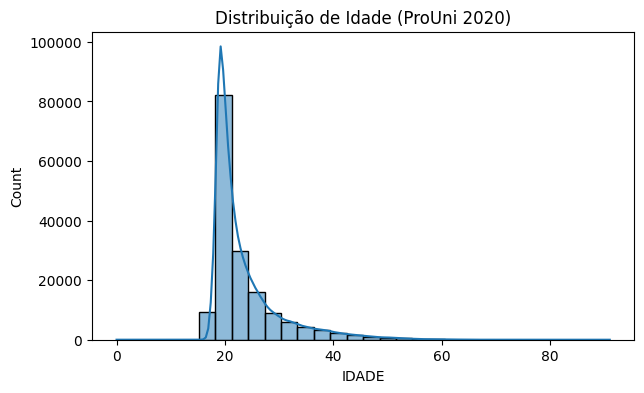

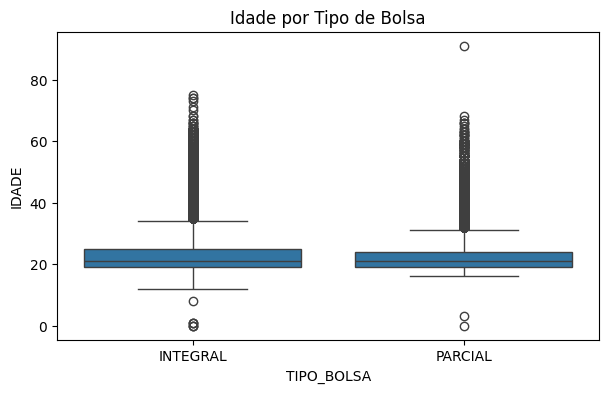

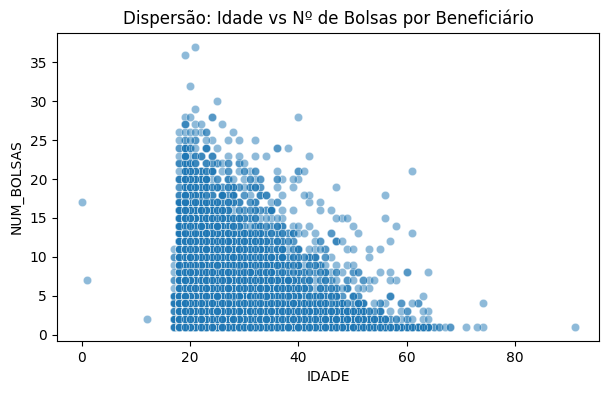

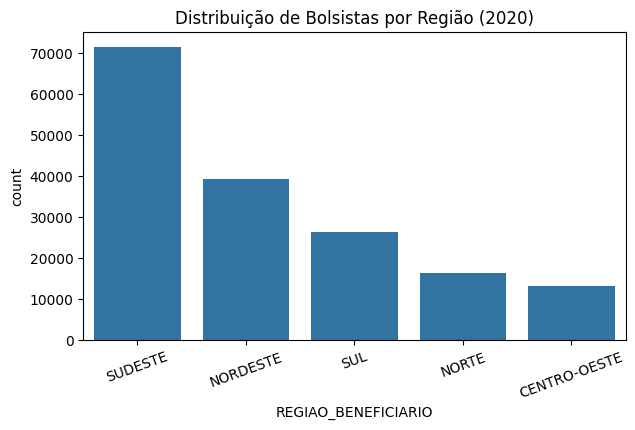

In [14]:
# 1) Histograma
plt.figure(figsize=(7,4))
sns.histplot(df["IDADE"], bins=30, kde=True)
plt.title("Distribuição de Idade (ProUni 2020)")
plt.show()

# 2) Boxplot
plt.figure(figsize=(7,4))
sns.boxplot(x="TIPO_BOLSA", y="IDADE", data=df)
plt.title("Idade por Tipo de Bolsa")
plt.show()

# 3) Dispersão numérica: idade vs nº de bolsas por beneficiário
if "CPF_BENEFICIARIO" in df.columns:
    bolsas_por_cpf = df.groupby("CPF_BENEFICIARIO").size().rename("NUM_BOLSAS").reset_index()
    aux = df[["CPF_BENEFICIARIO","IDADE"]].drop_duplicates("CPF_BENEFICIARIO").merge(bolsas_por_cpf, on="CPF_BENEFICIARIO")
    plt.figure(figsize=(7,4))
    sns.scatterplot(x="IDADE", y="NUM_BOLSAS", data=aux, alpha=0.5)
    plt.title("Dispersão: Idade vs Nº de Bolsas por Beneficiário")
    plt.show()

# 4) Barras por região
plt.figure(figsize=(7,4))
ordem = df["REGIAO_BENEFICIARIO"].value_counts().index
sns.countplot(x="REGIAO_BENEFICIARIO", data=df, order=ordem)
plt.title("Distribuição de Bolsistas por Região (2020)")
plt.xticks(rotation=20)
plt.show()

## 7. Comentários e Insights

- **Idade (média x mediana):** quando a gente compara a média com a mediana dá pra ver que as idades não ficam distribuídas “certinhas” em volta de um ponto. Tem uma parte do pessoal com idade mais alta que acaba puxando a média para cima, então a mediana costuma representar melhor a idade “típica”.

- **Idades bem acima do comum (outliers):** usando o IQR aparecem alguns casos com idade bem maior do que a maioria. Isso pode ser real (pessoas mais velhas voltando a estudar) ou pode indicar registros fora do padrão que valem atenção.

- **Valores ausentes:** no geral, o dataset tem poucos campos vazios, o que ajuda bastante na análise. Quando alguma coluna específica tem mais faltantes (ex.: informações de curso/campus), as conclusões daquele recorte ficam menos confiáveis.

- **Diferença por região/UF:** olhando a contagem por **região** e **UF**, dá pra perceber que as bolsas não ficam igualmente distribuídas pelo país. Regiões mais populosas ou com mais oferta de instituições tendem a concentrar mais beneficiários.

- **Data “estranha” (31/12/1969):** apareceu várias vezes `31/12/1969` como data de nascimento, o que parece ser um valor “padrão” usado quando a data real não foi informada. Por isso tratei esse valor como ausente para não bagunçar o cálculo da idade.

- **Resumo:** no recorte de 2020, a maior parte dos beneficiários está em faixas etárias mais jovens, mas existem alguns casos de idades mais altas (outliers). Também fica claro que há concentração de bolsas em algumas regiões/UFs.